# Modelagem — previsão de município que atinge a meta de alfabetização

Problema: classificação binária supervisionada. Target `atingiu_meta` = o município atingiu a própria meta oficial de alfabetização do INEP naquele ano. Unidade de análise: município × ano (2023, 2024).

Pipeline (`src/modeling/pipeline.py`): `ColumnTransformer` com imputação, transformação log + escala para `populacao`/`pib`, escala para os indicadores educacionais, one-hot encoding para `sigla_uf` — tudo integrado a um único `Pipeline` sklearn junto com o modelo, para eliminar risco de vazamento entre pré-processamento e treino/teste. Três candidatos comparados por validação cruzada (Regressão Logística, Random Forest, Gradient Boosting), o campeão passa por `RandomizedSearchCV` e é avaliado num holdout nunca visto, além de uma validação temporal fora da amostra (treina em 2023, testa em 2024).

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, "..")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve

from src.modeling.pipeline import FEATURE_COLUMNS, TARGET
from src.evaluation.metrics import classification_metrics
from src.visualization.plots import plot_confusion_matrix, plot_roc_curve, plot_feature_importance

sns.set_theme(style="whitegrid")
IMAGES_DIR = Path("../images")

df = pd.read_parquet("../data/processed/municipio_alfabetizacao_enriquecido.parquet")
with open("../reports/model_metrics.json", encoding="utf-8") as f:
    report = json.load(f)
report["modelo_campeao"], report["melhores_hiperparametros"]

('logistic_regression', {'model__C': 0.1})

In [2]:
X = df[FEATURE_COLUMNS]
y = df[TARGET].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Treino: {X_train.shape[0]} linhas | Teste: {X_test.shape[0]} linhas")
print(f"Proporção da classe positiva — treino: {y_train.mean():.3f} | teste: {y_test.mean():.3f}")

Treino: 7936 linhas | Teste: 1985 linhas
Proporção da classe positiva — treino: 0.393 | teste: 0.393


Mesmo `random_state=42` usado em `src/modeling/train_model.py`, então esse split reproduz exatamente o conjunto de teste usado no treino original — o modelo carregado abaixo nunca viu essas linhas.

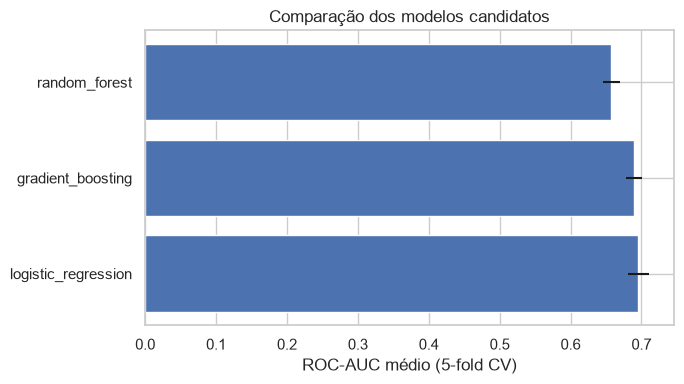

,modelo,media,desvio_padrao
0,logistic_regression,0.695621,0.014720
1,gradient_boosting,0.689096,0.011618
2,random_forest,0.657548,0.012209


In [3]:
comparacao = pd.DataFrame(report["cv_comparacao_candidatos"])
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(comparacao["modelo"], comparacao["media"], xerr=comparacao["desvio_padrao"], color="#4C72B0")
ax.set_xlabel("ROC-AUC médio (5-fold CV)")
ax.set_title("Comparação dos modelos candidatos")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "09_comparacao_modelos.png", dpi=120)
plt.show()
comparacao

A Regressão Logística venceu a comparação (ROC-AUC médio 0,696), à frente do Gradient Boosting (0,689) e do Random Forest (0,658). Isso contraria a hipótese levantada na EDA — de que modelos baseados em árvore capturariam melhor as interações não-lineares. Com um conjunto de features relativamente pequeno e um sinal predominantemente geográfico (a UF concentra boa parte do sinal, como visto adiante nos coeficientes), um modelo linear regularizado generaliza melhor nesse volume de dados do que árvores mais complexas, que tendem a overfitar padrões espúrios num dataset de ~8 mil linhas de treino. Fica registrado como uma hipótese que não se confirmou — não vamos forçar a explicação de que "árvores são sempre melhores" só porque parecia razoável na EDA.

In [4]:
pipeline = joblib.load("../models/pipeline_final.joblib")
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]
metrics_holdout = classification_metrics(y_test, y_pred, y_proba)
pd.Series(metrics_holdout).round(4)

accuracy     0.6408
precision    0.5630
recall       0.3892
f1           0.4603
roc_auc      0.6745
dtype: float64

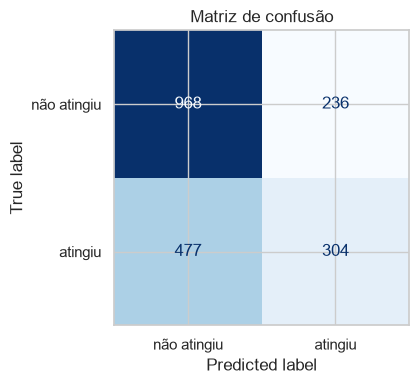

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion_matrix(y_test, y_pred, ax=ax)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "10_matriz_confusao.png", dpi=120)
plt.show()

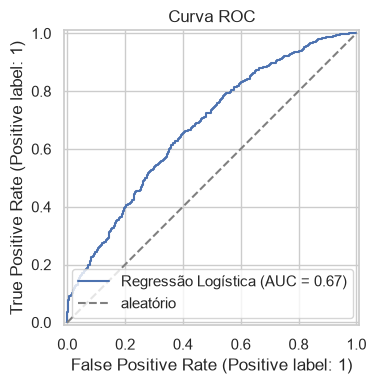

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
plot_roc_curve(y_test, y_proba, ax=ax, label="Regressão Logística")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "11_curva_roc.png", dpi=120)
plt.show()

ROC-AUC de 0,67 no holdout: o modelo discrimina melhor que aleatório, mas está longe de perfeito — esperado, dado que nosso conjunto de features não tem informação socioeconômica no nível de detalhe do IDHM ou de renda familiar (não encontramos essas fontes prontas no Base dos Dados, ver EDA). Com o threshold padrão de 0,5, o recall fica em 0,39 — o modelo deixa passar mais de 60% dos municípios que de fato não batem a meta. Para o caso de uso de política pública (priorizar municípios de risco), isso é um problema: é pior deixar de identificar um município que precisa de apoio do que sinalizar um a mais que não precisava. Vale ajustar o threshold de decisão, não usar o padrão de 0,5 — ver célula seguinte.

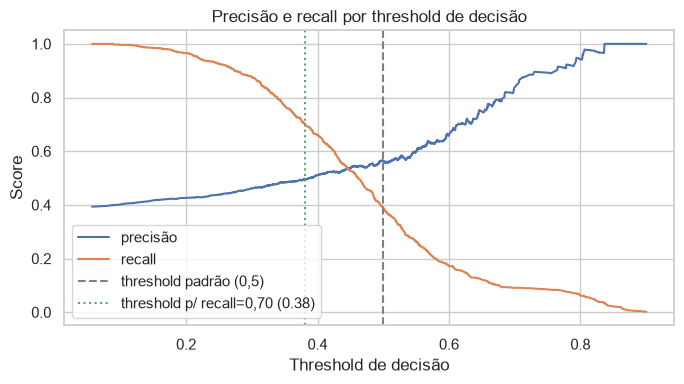

No threshold 0.381: recall=0.700, precisão=0.496


In [7]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, precision[:-1], label="precisão", color="#4C72B0")
ax.plot(thresholds, recall[:-1], label="recall", color="#DD8452")
ax.axvline(0.5, color="gray", linestyle="--", label="threshold padrão (0,5)")
idx_recall_70 = np.where(recall[:-1] >= 0.7)[0]
threshold_recall_70 = thresholds[idx_recall_70[np.argmax(thresholds[idx_recall_70])]]
ax.axvline(threshold_recall_70, color="#55A868", linestyle=":", label=f"threshold p/ recall=0,70 ({threshold_recall_70:.2f})")
ax.set_xlabel("Threshold de decisão")
ax.set_ylabel("Score")
ax.set_title("Precisão e recall por threshold de decisão")
ax.legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / "12_precisao_recall_threshold.png", dpi=120)
plt.show()
print(f"No threshold {threshold_recall_70:.3f}: recall={recall[idx_recall_70[np.argmax(thresholds[idx_recall_70])]]:.3f}, precisão={precision[idx_recall_70[np.argmax(thresholds[idx_recall_70])]]:.3f}")

Baixando o threshold de decisão de 0,5 para ≈0,38, o modelo passa a identificar 70% dos municípios que de fato não vão atingir a meta (recall 0,70), ao custo de acertar só ~50% das vezes quando sinaliza risco (precisão ≈0,50). Para uma política pública de baixo custo (ex.: visita técnica, reforço de material), esse é um trade-off aceitável — melhor investigar municípios que acabam não precisando do que deixar passar municípios que precisavam. Esse é o threshold que recomendamos para uso do modelo como ferramenta de triagem, não o padrão de 0,5 usado para a métrica de F1 acima.

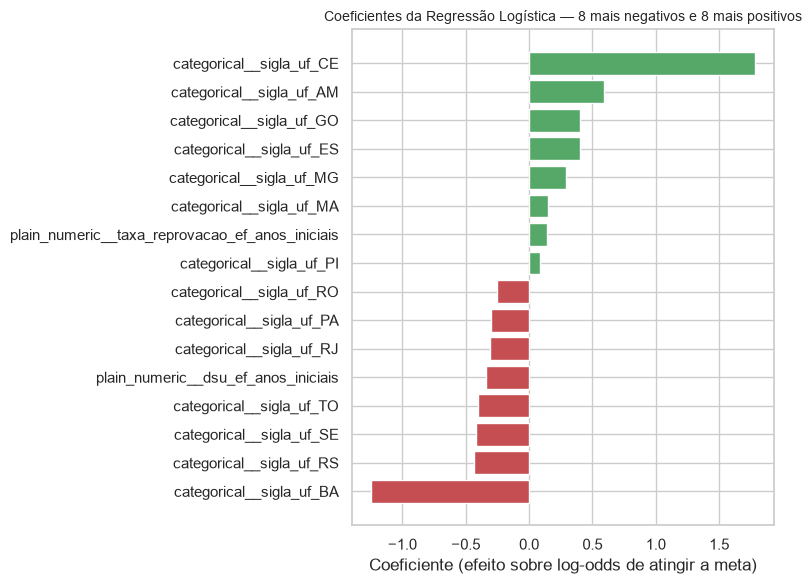

In [8]:
preprocessor = pipeline.named_steps["preprocessor"]
model = pipeline.named_steps["model"]
feature_names = preprocessor.get_feature_names_out()
coef_df = pd.DataFrame({"feature": feature_names, "coef": model.coef_[0]}).sort_values("coef")

top_coef = pd.concat([coef_df.head(8), coef_df.tail(8)])
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#C44E52" if v < 0 else "#55A868" for v in top_coef["coef"]]
ax.barh(top_coef["feature"], top_coef["coef"], color=colors)
ax.set_title("Coeficientes da Regressão Logística — 8 mais negativos e 8 mais positivos", fontsize=10)
ax.set_xlabel("Coeficiente (efeito sobre log-odds de atingir a meta)")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "13_coeficientes.png", dpi=120)
plt.show()

O sinal mais forte do modelo é geográfico: **Bahia (BA) é o coeficiente mais negativo de todo o modelo** (-1,24), à frente até do Rio Grande do Sul (-0,44, nosso caso investigado na EDA), seguido por Sergipe (SE) e Tocantins (TO). No lado positivo, **Ceará (CE) tem o coeficiente mais alto** (+1,78), consistente com o que já tínhamos visto na EDA (CE era a UF com maior taxa de atingimento da meta em 2024). `dsu_ef_anos_iniciais` (% de docentes com curso superior) aparece entre os coeficientes negativos mais fortes fora do bloco geográfico — confirma, agora dentro do modelo treinado, o padrão contraintuitivo que já tínhamos sinalizado como não resolvido na EDA.

Background dataset has 7936 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=7936 when initializing the masker.


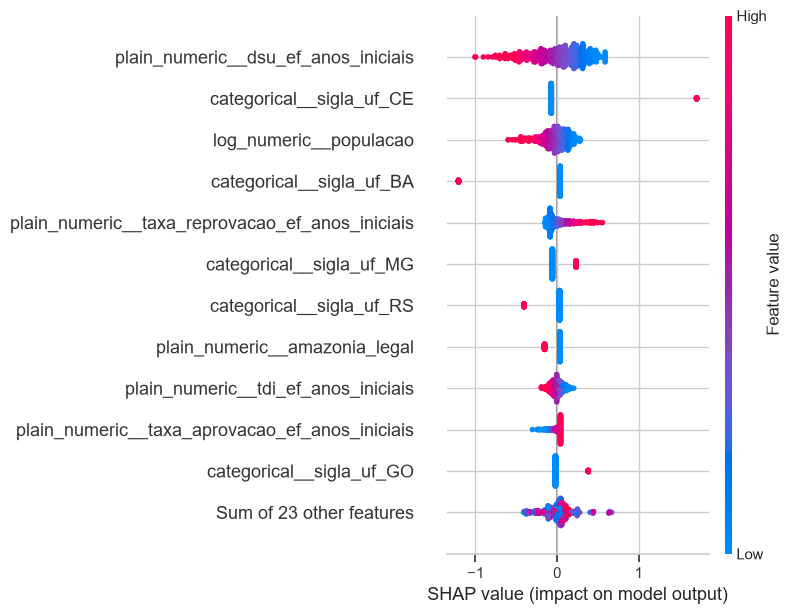

In [9]:
X_train_t = preprocessor.transform(X_train)
X_test_t = preprocessor.transform(X_test)
if hasattr(X_test_t, "toarray"):
    X_train_t = X_train_t.toarray()
    X_test_t = X_test_t.toarray()

explainer = shap.LinearExplainer(model, X_train_t, feature_names=feature_names)
shap_values = explainer(X_test_t[:500])

fig, ax = plt.subplots(figsize=(8, 6))
shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "14_shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()

O SHAP (calculado nas primeiras 500 linhas do conjunto de teste) confirma `dsu_ef_anos_iniciais` como a variável de maior impacto médio nas previsões individuais, à frente até das dummies de UF isoladas — o que faz sentido, já que o efeito geográfico está espalhado entre várias colunas de `sigla_uf` (uma por estado), enquanto `dsu_ef_anos_iniciais` concentra seu efeito numa única coluna numérica. `populacao` e a taxa de reprovação nos anos iniciais também aparecem entre as variáveis mais influentes — coerente com a exploração feita na EDA.

In [10]:
pd.Series(report["metricas_validacao_temporal_2023_para_2024"]).round(4)

accuracy     0.4641
precision    0.5131
recall       0.0902
f1           0.1534
roc_auc      0.5535
dtype: float64

**Achado mais importante desta etapa, e o principal limite do modelo.** Quando treinado só com dados de 2023 e avaliado em 2024 (município nunca visto pelo modelo *nesse ano*), o desempenho cai muito: ROC-AUC de 0,55 (quase aleatório) e recall de apenas 0,09 — o modelo deixa de identificar 91% dos municípios que não bateram a meta em 2024.

A explicação está ligada ao que já tínhamos visto na EDA: a taxa de alfabetização subiu de forma real e generalizada entre 2023 e 2024 (23,2% dos municípios batendo a meta em 2023 contra 53,8% em 2024). Um modelo treinado só com o padrão de 2023 aprende que "bater a meta" é um evento raro, e carrega esse viés para 2024 — mesmo que o perfil territorial/educacional de cada município não tenha mudado tanto assim de um ano para o outro, o patamar nacional mudou, e o modelo não tem nenhuma feature que capture esse tipo de mudança de contexto (política pública, mobilização nacional, ou qualquer outro fator de ano).

**Implicação prática:** o modelo é útil para comparar o risco *relativo* entre municípios dentro do mesmo ciclo de avaliação (por isso o holdout aleatório funciona razoavelmente — ROC-AUC 0,67), mas não deve ser usado para prever o patamar nacional de um ano ainda não observado sem recalibração. Isso é uma limitação estrutural, não um defeito do pipeline, e precisa ficar explícita na aplicação do modelo para política pública.

## Municípios de maior risco

Pergunta de negócio: quais municípios estão em maior risco de não atingir a meta? Em vez de
responder só de forma agregada (sinal de UF, segmento próximo da meta), aplicamos o pipeline
campeão ao snapshot de 2024 completo e ranqueamos os municípios pela menor probabilidade prevista
de atingir a meta — a mesma lógica usada em `src/modeling/predict_risk.py`
(`python src/modeling/predict_risk.py` gera o ranking completo em
`reports/ranking_risco_municipios.csv`).

In [11]:
proba_atingir_meta = pipeline.predict_proba(df[df["ano"] == 2024][FEATURE_COLUMNS])[:, 1]

snapshot_2024 = df[df["ano"] == 2024].reset_index(drop=True)
ranking = snapshot_2024[
    ["nome_municipio", "sigla_uf", "taxa_alfabetizacao", "meta_alfabetizacao_2024", "atingiu_meta"]
].copy()
ranking["probabilidade_prevista_atingir_meta"] = proba_atingir_meta.round(4)
ranking = ranking.sort_values("probabilidade_prevista_atingir_meta").reset_index(drop=True)
ranking.insert(0, "ranking_risco", ranking.index + 1)

top20 = ranking.head(20)
print(f"% do Top 20 que de fato não atingiu a meta em 2024: {(top20['atingiu_meta'] == 0).mean():.0%}")
top20.drop(columns=["meta_alfabetizacao_2024"])

% do Top 20 que de fato não atingiu a meta em 2024: 90%


,ranking_risco,nome_municipio,sigla_uf,taxa_alfabetizacao,atingiu_meta,probabilidade_prevista_atingir_meta
0,1,Almadina,BA,23.91,0,0.0558
1,2,Salvador,BA,36.85,0,0.0613
2,3,Canavieiras,BA,28.68,0,0.0628
3,4,Valença,BA,31.89,0,0.0642
4,5,Adustina,BA,42.45,0,0.0646
5,6,Antônio Cardoso,BA,25.76,0,0.0678
6,7,Pilão Arcado,BA,22.51,0,0.0682
7,8,Ilhéus,BA,26.63,0,0.0690
8,9,Ipirá,BA,34.46,0,0.0696
9,10,Feira de Santana,BA,33.19,0,0.0696


**90% dos 20 municípios apontados como maior risco de fato não atingiram a meta em 2024** — um
resultado forte, mas que também expõe uma limitação do modelo: **os 20 primeiros colocados são
quase todos da Bahia**. Como o coeficiente de UF domina a previsão (ver seção de interpretação
acima), o ranking de risco tende a replicar o padrão estadual em vez de diferenciar municípios
dentro do mesmo estado por seu perfil individual. Útil como primeiro filtro geográfico para
política pública, mas caberia complementar com um modelo por UF ou features municipais mais
granulares numa evolução futura, para não tratar todos os municípios de um estado como igualmente
prioritários. A pergunta sobre regiões com padrões semelhantes é aprofundada à parte, em
`03_clustering.ipynb`.

## Síntese

- **Modelo campeão**: Regressão Logística (`C=0,1`), escolhida entre 3 candidatos por validação cruzada — não Random Forest/Gradient Boosting, contrariando a expectativa inicial da EDA.
- **Desempenho**: ROC-AUC 0,67 em holdout aleatório (discrimina melhor que aleatório, moderado); recall baixo no threshold padrão, mas recuperável ajustando o ponto de corte para uso como ferramenta de triagem (recall 0,70 a um threshold de ≈0,38).
- **O que mais pesa na previsão**: geografia (UF — Bahia e Sergipe como sinais negativos fortes, Ceará como sinal positivo forte) e `dsu_ef_anos_iniciais` (% de docentes com curso superior, com efeito negativo ainda sem explicação causal clara).
- **Limitação central**: o modelo não generaliza bem entre anos diferentes (ROC-AUC cai para 0,55 treinando em 2023 e testando em 2024) — serve para ranquear risco relativo dentro de um mesmo ciclo, não para prever o patamar nacional de um ano futuro sem recalibração.
- **Municípios de maior risco**: o ranking por probabilidade prevista acerta 90% no Top 20, mas essa lista sai quase toda da Bahia — reflexo direto do peso da UF no modelo, não de um diagnóstico fino por município.
- A pergunta sobre quais regiões têm padrões semelhantes entre si é respondida à parte, por clusterização, em `03_clustering.ipynb`.